Improving an Underfitting Model

Let’s try to address our model’s **underfitting** problem.

Focusing specifically on the **model itself** (not the data), there are several common techniques we can use to increase its capacity to learn more complex patterns.

### Model Improvement Techniques

| Model improvement technique* | What does it do? |
| ----- | ----- |
| **Add more layers** | Each additional layer can increase the model’s ability to learn hierarchical and more complex patterns. Models with more layers are often described as being *deeper*. |
| **Add more hidden units** | Increasing the number of hidden units in a layer can improve the model’s representational power. Models with more units per layer are often described as being *wider*. |
| **Train for longer (more epochs)** | Giving the model more passes over the training data can allow it to learn patterns it may not have captured initially. |
| **Change activation functions** | Linear activations limit what a model can learn. Non-linear activation functions allow the model to capture more complex relationships in the data. |
| **Adjust the learning rate** | The learning rate controls how much the model updates its parameters each step. Too high can cause instability; too low can slow or stall learning. |
| **Change the loss function** | The loss function defines what “good performance” means. Using an inappropriate loss function can prevent the model from learning effectively. |
| **Use transfer learning** | Leveraging a pretrained model from a related task can significantly improve performance, especially with limited data. |

> **Note:** Because these settings are chosen *before* training and tuned manually, they are referred to as **hyperparameters**.

**Let's try adding activation functions:**

In [1]:
import pandas as pd

path = r'..\..\Old_Syllabus\Lab3-NN\binary_classification_moons.csv'

data = pd.read_csv(path)
data.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


In [2]:
# vectorizing X1 and X2 into a single tensor/nparray

X = data[['X1', 'X2']].values
y = data['label'].values

In [3]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

C:\Users\HP\AppData\Local\Temp\ipykernel_20896\1521810368.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y = torch.from_numpy(y).type(torch.float)


(800, 200, 800, 200)

In [4]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [5]:
# Build model with non-linear activation function
from torch import nn
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = ModelV2().to(device)
print(model_2)

ModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [6]:
from utils import train_and_test_loop, plot_decision_boundary
import matplotlib.pyplot as plt

Epoch: 0 | Loss: 0.74563, Accuracy: 50.00% | Test loss: 0.73329, Test acc: 50.00%
Epoch: 10 | Loss: 0.70815, Accuracy: 50.00% | Test loss: 0.70297, Test acc: 50.00%
Epoch: 20 | Loss: 0.68914, Accuracy: 50.00% | Test loss: 0.68696, Test acc: 50.00%
Epoch: 30 | Loss: 0.67428, Accuracy: 50.00% | Test loss: 0.67400, Test acc: 50.00%
Epoch: 40 | Loss: 0.65836, Accuracy: 77.38% | Test loss: 0.65975, Test acc: 74.50%
Epoch: 50 | Loss: 0.63858, Accuracy: 79.12% | Test loss: 0.64203, Test acc: 76.50%
Epoch: 60 | Loss: 0.61432, Accuracy: 78.25% | Test loss: 0.62030, Test acc: 75.50%
Epoch: 70 | Loss: 0.58412, Accuracy: 77.38% | Test loss: 0.59322, Test acc: 76.00%
Epoch: 80 | Loss: 0.54828, Accuracy: 78.00% | Test loss: 0.56131, Test acc: 75.50%
Epoch: 90 | Loss: 0.50976, Accuracy: 78.12% | Test loss: 0.52685, Test acc: 73.50%


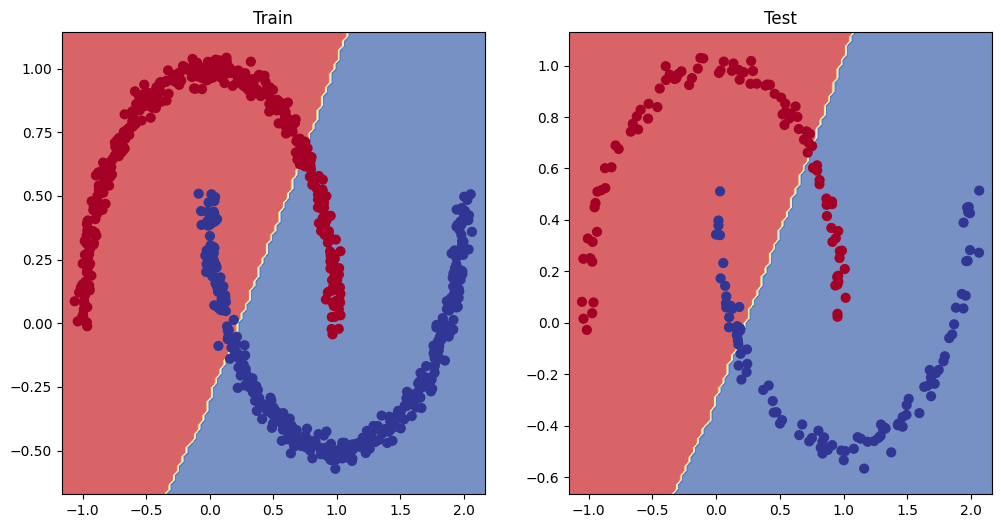

In [7]:
model = model_2
epochs = 100

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

Let's train more ...


Epoch: 0 | Loss: 0.68880, Accuracy: 50.00% | Test loss: 0.68613, Test acc: 50.00%
Epoch: 10 | Loss: 0.66684, Accuracy: 50.00% | Test loss: 0.66496, Test acc: 50.00%
Epoch: 20 | Loss: 0.63929, Accuracy: 50.00% | Test loss: 0.63801, Test acc: 50.00%
Epoch: 30 | Loss: 0.60478, Accuracy: 75.88% | Test loss: 0.60450, Test acc: 78.50%
Epoch: 40 | Loss: 0.56116, Accuracy: 85.50% | Test loss: 0.56241, Test acc: 85.00%
Epoch: 50 | Loss: 0.51217, Accuracy: 86.12% | Test loss: 0.51607, Test acc: 83.50%
Epoch: 60 | Loss: 0.46412, Accuracy: 85.62% | Test loss: 0.47057, Test acc: 81.50%
Epoch: 70 | Loss: 0.42054, Accuracy: 85.25% | Test loss: 0.42931, Test acc: 82.00%
Epoch: 80 | Loss: 0.38399, Accuracy: 85.38% | Test loss: 0.39430, Test acc: 82.00%
Epoch: 90 | Loss: 0.35521, Accuracy: 85.75% | Test loss: 0.36611, Test acc: 83.00%
Epoch: 100 | Loss: 0.33320, Accuracy: 86.00% | Test loss: 0.34390, Test acc: 83.50%
Epoch: 110 | Loss: 0.31644, Accuracy: 86.25% | Test loss: 0.32634, Test acc: 84.50%
Epo

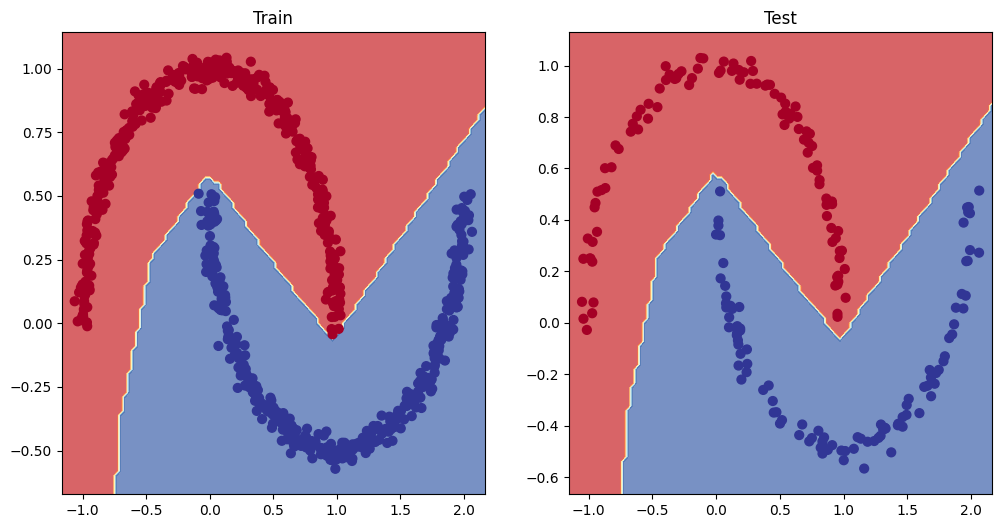

In [8]:
epochs = 1000
model = ModelV2().to(device) # reset model
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

**This is the reason why Activation Function is necessary:**
![Neuron](https://towardsdatascience.com/wp-content/uploads/2021/12/1hkYlTODpjJgo32DoCOWN5w.png)

An example of a neural network with activation functions is shown below.

![NN with activation](https://lamarr-institute.org/wp-content/uploads/deepLearn_2_EN.png)
 
> `Note:` 
When looking at a neural network diagram, it is generally assumed that each neuron applies an activation function to its weighted input, unless stated otherwise.


Epoch: 0 | Loss: 0.72189, Accuracy: 39.88% | Test loss: 0.71557, Test acc: 45.50%
Epoch: 10 | Loss: 0.69783, Accuracy: 50.62% | Test loss: 0.69572, Test acc: 52.00%
Epoch: 20 | Loss: 0.68381, Accuracy: 52.00% | Test loss: 0.68459, Test acc: 51.50%
Epoch: 30 | Loss: 0.67196, Accuracy: 61.50% | Test loss: 0.67486, Test acc: 62.00%
Epoch: 40 | Loss: 0.65778, Accuracy: 67.50% | Test loss: 0.66313, Test acc: 63.50%
Epoch: 50 | Loss: 0.63882, Accuracy: 70.00% | Test loss: 0.64709, Test acc: 63.00%
Epoch: 60 | Loss: 0.61324, Accuracy: 72.50% | Test loss: 0.62492, Test acc: 64.00%
Epoch: 70 | Loss: 0.57925, Accuracy: 74.75% | Test loss: 0.59394, Test acc: 68.00%
Epoch: 80 | Loss: 0.53675, Accuracy: 77.00% | Test loss: 0.55326, Test acc: 71.50%
Epoch: 90 | Loss: 0.49132, Accuracy: 79.38% | Test loss: 0.51002, Test acc: 74.00%
Epoch: 100 | Loss: 0.44884, Accuracy: 80.38% | Test loss: 0.46893, Test acc: 76.00%
Epoch: 110 | Loss: 0.40979, Accuracy: 81.62% | Test loss: 0.43038, Test acc: 77.50%
Epo

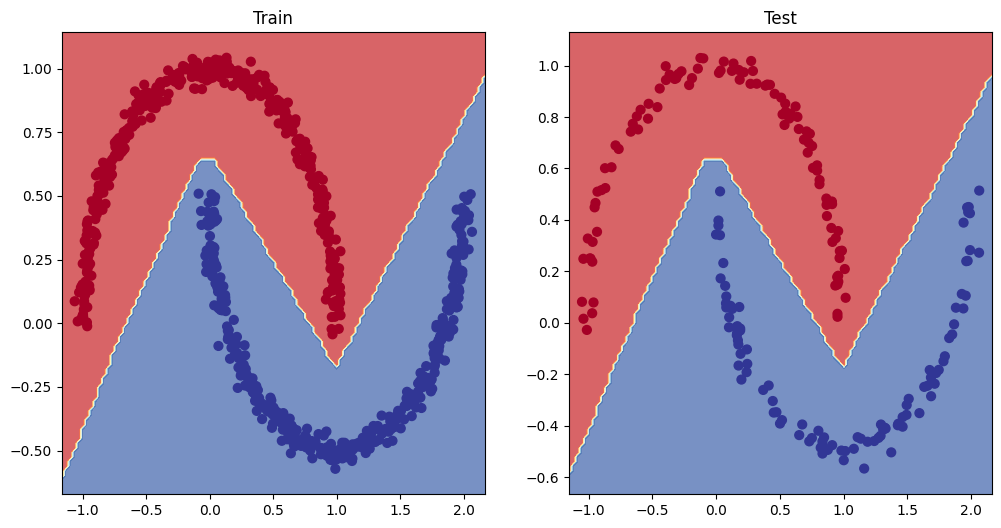

In [9]:
model = ModelV2().to(device) # reset model
epochs = 1500
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)